# Alzheimer's Disease Classification: Model Training & Evaluation

### Overview
Following the Exploratory Data Analysis, this notebook focuses on data preprocessing and building machine learning models.

I will evaluate our models using two distinct datasets:
1.  All Features: Training models on every available feature.
2.  Selected Features: Training models exclusively on the features that demonstrated statistical or strong visual significance during the EDA phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

df = pd.read_csv(os.path.join('..', 'data', 'alzheimers_disease_data.csv'))
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,0.238667,0,0,4.492838,1,0,0,0,0,1
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,8.687480,0,1,9.204952,0,0,0,0,0,1
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,1.972137,0,0,5.036334,0,0,0,0,0,1
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,...,5.173891,0,0,3.785399,0,0,0,0,1,1


In [3]:
y = df['Diagnosis']
X_all = df.drop('Diagnosis', axis=1)

# based on our statistical and visualization analyses
selected_columns = [
    'FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 
    'BehavioralProblems', 'SleepQuality', 'CholesterolHDL', 'CholesterolTriglycerides',
    'Hypertension', 'CardiovascularDisease'
]
X_selected = df[selected_columns]

# Total features available:
X_all.shape[1]

32

In [4]:
RANDOM_STATE = 85

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train_selected = X_train_all[selected_columns]
X_test_selected = X_test_all[selected_columns]

#### Checking for Outliers

In [5]:
def check_outliers_iqr(dataframe, features):
    outlier_counts = {}
    for col in features:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        if len(outliers) > 0:
            outlier_counts[col] = len(outliers)
            
    return outlier_counts

continuous_features = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

outliers_found = check_outliers_iqr(X_train_all, continuous_features)
outliers_found if outliers_found else "No outliers detected."

'No outliers detected.'

### Feature Encoding

- Binary features: (e.g., `Gender`) are already 0/1.
- Ordinal features: `EducationLevel` has a natural hierarchy (0 to 3), so integer encoding is valid.
- Nominal features `Ethnicity` is the only feature, we will apply a one-hot encoding.

In [6]:
X_train_all_encoded = pd.get_dummies(X_train_all, columns=['Ethnicity'], dtype=int)
X_test_all_encoded = pd.get_dummies(X_test_all, columns=['Ethnicity'], dtype=int)

### Feature Scaling

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_all_scaled = X_train_all_encoded.copy()
X_test_all_scaled = X_test_all_encoded.copy()

X_train_all_scaled[continuous_features] = scaler.fit_transform(X_train_all_encoded[continuous_features])
X_test_all_scaled[continuous_features] = scaler.transform(X_test_all_encoded[continuous_features])

X_train_selected_scaled = X_train_all_scaled[selected_columns].copy()
X_test_selected_scaled = X_test_all_scaled[selected_columns].copy()

X_train_all_scaled.head()

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Ethnicity_0,Ethnicity_1,Ethnicity_2,Ethnicity_3
600,0.433333,0,1,0.651455,1,0.527488,0.520995,0.962975,0.238509,0,...,0.278475,0,0,0,0,0,1,0,0,0
1137,0.433333,0,2,0.201806,0,0.287530,0.840652,0.052615,0.517293,0,...,0.268888,0,0,0,0,1,0,1,0,0
923,0.000000,0,3,0.865325,0,0.897432,0.802327,0.759533,0.089110,0,...,0.422118,1,1,0,0,0,1,0,0,0
1400,0.600000,1,1,0.809807,1,0.268738,0.174621,0.111264,0.957298,1,...,0.972824,0,0,0,0,0,0,0,1,0
1913,0.133333,0,1,0.371190,0,0.976849,0.645794,0.547277,0.902804,0,...,0.592245,0,0,0,0,1,1,0,0,0


In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [9]:
# weight for models that use it [for class imbalance that we noted early in the EDA]
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM': SVC(random_state=RANDOM_STATE, class_weight='balanced', probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Gaussian Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ),
}

# Evaluate on ALL features
results_all = []
for name, model in models.items():
    f1_scores = cross_val_score(model, X_train_all_scaled, y_train, cv=5, scoring='f1_weighted')
    results_all.append({'Model': name, 'F1-Score (mean)': f1_scores.mean()})

results_all_df = pd.DataFrame(results_all)

# Evaluate on SELECTED features
results_selected = []
for name, model in models.items():
    f1_scores = cross_val_score(model, X_train_selected_scaled, y_train, cv=5, scoring='f1_weighted')
    results_selected.append({'Model': name, 'F1-Score (mean)': f1_scores.mean()})

results_selected_df = pd.DataFrame(results_selected)

In [10]:
results_all_df

,Model,F1-Score (mean)
0,Logistic Regression,0.818134
1,K-Nearest Neighbors,0.667493
2,SVM,0.818332
3,Decision Tree,0.891856
4,Gaussian Naive Bayes,0.778597
5,Random Forest,0.910685
6,XGBoost,0.942796


In [11]:
results_selected_df

,Model,F1-Score (mean)
0,Logistic Regression,0.828822
1,K-Nearest Neighbors,0.843131
2,SVM,0.853035
3,Decision Tree,0.905353
4,Gaussian Naive Bayes,0.806565
5,Random Forest,0.944332
6,XGBoost,0.938747


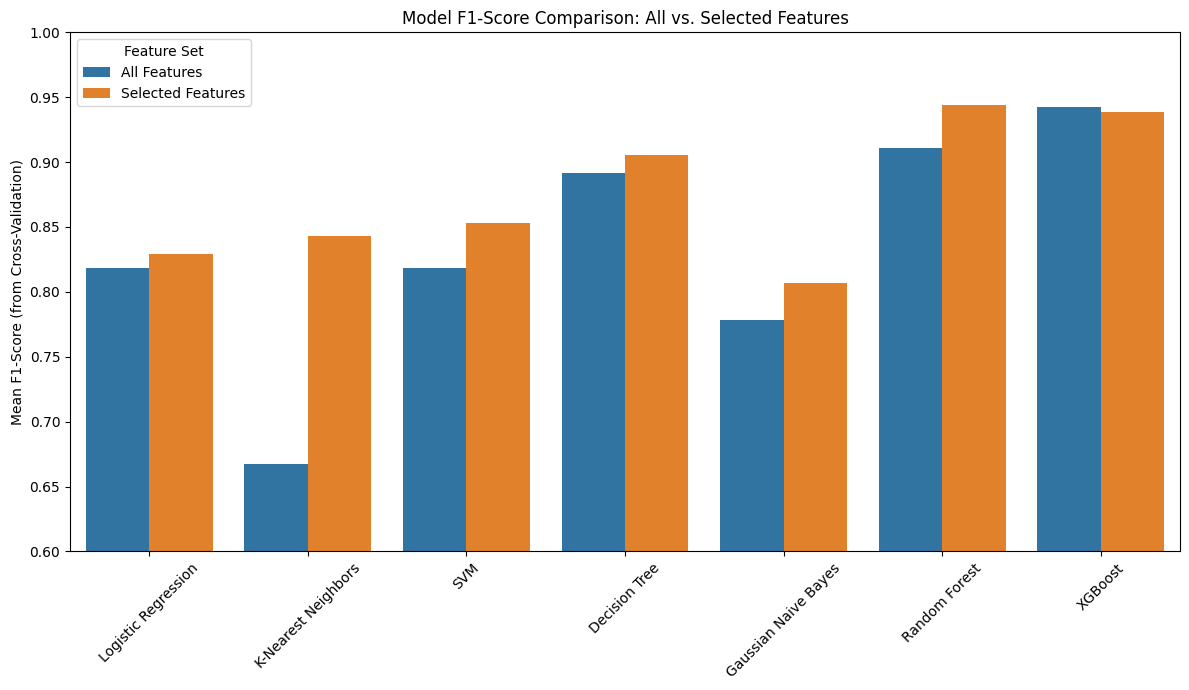

In [12]:
results_all_df['Feature Set'] = 'All Features'
results_selected_df['Feature Set'] = 'Selected Features'
comparison_df = pd.concat([results_all_df, results_selected_df])

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='F1-Score (mean)', hue='Feature Set', data=comparison_df)
plt.title('Model F1-Score Comparison: All vs. Selected Features')
plt.ylabel('Mean F1-Score (from Cross-Validation)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)
plt.legend(title='Feature Set')
plt.tight_layout()
plt.show()

The cross-validation results are clear:
- Random Forest and XGBoost are the top-performing models.
- The modeels trained on the selected features performed drastically or marginally better than those trained on all features.

Let's check how well those two models (Random Forest with selected features, and xgboost with all features) perform on the test set.

In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

final_rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
final_rf.fit(X_train_selected_scaled, y_train)
y_pred_rf = final_rf.predict(X_test_selected_scaled)
print(classification_report(y_test, y_pred_rf, target_names=["No Alzheimer's", "Alzheimer's"]))

                precision    recall  f1-score   support

No Alzheimer's       0.97      0.98      0.97       278
   Alzheimer's       0.96      0.95      0.95       152

      accuracy                           0.97       430
     macro avg       0.97      0.96      0.96       430
  weighted avg       0.97      0.97      0.97       430



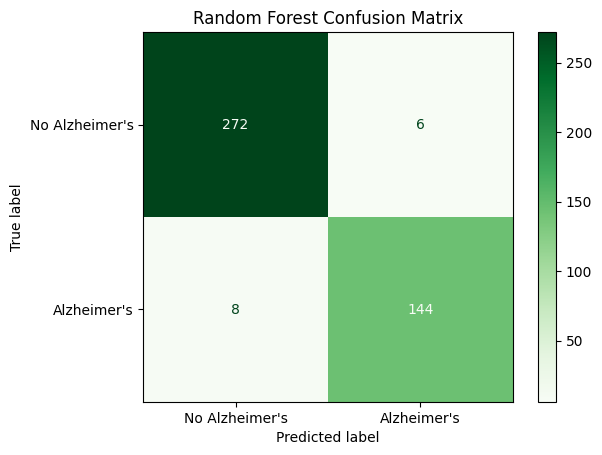

In [14]:
ConfusionMatrixDisplay.from_estimator(
    final_rf, X_test_selected_scaled, y_test, display_labels=["No Alzheimer's", "Alzheimer's"],
    cmap='Greens'
)
plt.title('Random Forest Confusion Matrix')
plt.show()

In [15]:
final_xgb = XGBClassifier(
    random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
final_xgb.fit(X_train_selected_scaled, y_train)
y_pred_xgb = final_xgb.predict(X_test_selected_scaled)
print(classification_report(y_test, y_pred_xgb, target_names=["No Alzheimer's", "Alzheimer's"]))

                precision    recall  f1-score   support

No Alzheimer's       0.97      0.97      0.97       278
   Alzheimer's       0.94      0.95      0.95       152

      accuracy                           0.96       430
     macro avg       0.96      0.96      0.96       430
  weighted avg       0.96      0.96      0.96       430



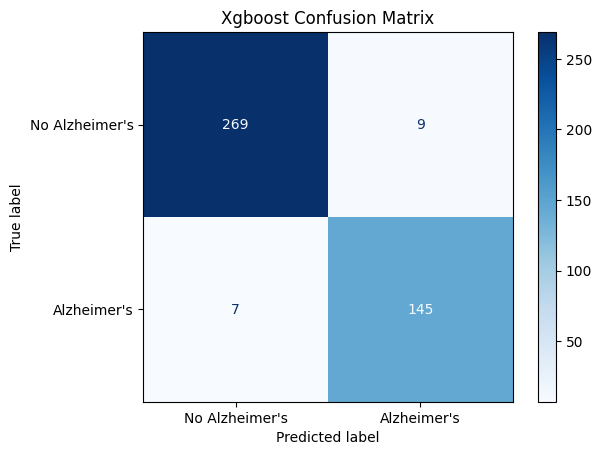

In [16]:
ConfusionMatrixDisplay.from_estimator(
    final_xgb, X_test_selected_scaled, y_test, display_labels=["No Alzheimer's", "Alzheimer's"],
    cmap='Blues'
)
plt.title('Xgboost Confusion Matrix')
plt.show()